In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from src.data.read_event_dataset import read_event_dataset
from src.data.read_curtailment_dataset import read_curtailment_dataset

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

MERGED_SCADA_DIR = PROJECT_ROOT / "data" / "interim" / "kelmarsh" / "merged_scada"
EVENT_PATH = PROJECT_ROOT / "data" / "raw" / "kelmarsh" / "auxiliary" / "kelmarsh_event_dataset.csv"
CURTAIL_PATH = PROJECT_ROOT / "data" / "raw" / "kelmarsh" / "auxiliary" / "kelmarsh_curtailment_dataset.csv"

In [2]:
INPUT_SIGNALS = [
    "Wind speed (m/s)",
    "Power (kW)",
    "Nacelle ambient temperature (°C)",
    "Nacelle temperature (°C)",
    "Generator RPM (RPM)",
    "Rotor speed (RPM)",
    "Stator temperature 1 (°C)",
    "Generator bearing front temperature (°C)",
]

TURBINE_OPTIONS = [f"Kelmarsh_{i}" for i in range(1, 7)]
MONTH_OPTIONS = []
for year in range(2016, 2023):
    for month in range(1, 13):
        MONTH_OPTIONS.append(f"{year}-{month:02d}")

In [3]:
def load_merged_scada_for_turbine(turbine_name: str) -> pd.DataFrame:
    path = MERGED_SCADA_DIR / f"{turbine_name.lower()}_scada_merged_raw_2016_2022.parquet"
    df = pd.read_parquet(path)
    df["Date and time"] = pd.to_datetime(df["Date and time"], errors="coerce")
    df = df[df["Date and time"].notna()].copy()
    return df.sort_values("Date and time").reset_index(drop=True)

In [4]:
def plot_signal_view(
    turbine_name: str,
    signal: str,
    start_month: str,
    end_month: str,
    show_event: bool = True,
    show_curtailment: bool = False,
    max_shaded_windows: int = 300,
):
    start_ts = pd.to_datetime(start_month + "-01")

    # end_month 取该月最后一天的 23:59:59
    end_ts = pd.to_datetime(end_month + "-01") + pd.offsets.MonthEnd(1)

    if start_ts > end_ts:
        print("Start month must be earlier than or equal to end month.")
        return

    scada_df = load_merged_scada_for_turbine(turbine_name)

    mask = (
        (scada_df["Date and time"] >= start_ts) &
        (scada_df["Date and time"] <= end_ts)
    )
    scada_plot = scada_df.loc[mask].copy()

    if scada_plot.empty:
        print("No SCADA data found in the selected month range.")
        return

    event_df = read_event_dataset(EVENT_PATH, turbine_filter=turbine_name)
    curtail_df = read_curtailment_dataset(CURTAIL_PATH, turbine_filter=turbine_name)

    plt.figure(figsize=(16, 5))
    plt.plot(scada_plot["Date and time"], scada_plot[signal], linewidth=0.8, label=signal)

    if show_event and not event_df.empty:
        ev = event_df[
            (event_df["Timestamp start"] <= scada_plot["Date and time"].max()) &
            (event_df["Timestamp end"] >= scada_plot["Date and time"].min())
        ].copy().head(max_shaded_windows)

        for _, row in ev.iterrows():
            if pd.notna(row["Timestamp start"]) and pd.notna(row["Timestamp end"]):
                plt.axvspan(row["Timestamp start"], row["Timestamp end"], alpha=0.15)

    if show_curtailment and not curtail_df.empty:
        cu = curtail_df[
            (curtail_df["Timestamp start"] <= scada_plot["Date and time"].max()) &
            (curtail_df["Timestamp end"] >= scada_plot["Date and time"].min())
        ].copy().head(max_shaded_windows)

        for _, row in cu.iterrows():
            if pd.notna(row["Timestamp start"]) and pd.notna(row["Timestamp end"]):
                plt.axvspan(row["Timestamp start"], row["Timestamp end"], alpha=0.10)

    plt.title(f"{turbine_name} | {signal} | {start_month} to {end_month}")
    plt.xlabel("Time")
    plt.ylabel(signal)
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(scada_plot[signal].describe())

In [5]:
turbine_dropdown = widgets.Dropdown(
    options=TURBINE_OPTIONS,
    value="Kelmarsh_1",
    description="Turbine:"
)

signal_dropdown = widgets.Dropdown(
    options=INPUT_SIGNALS,
    value="Generator bearing front temperature (°C)",
    description="Signal:"
)

start_month_dropdown = widgets.Dropdown(
    options=MONTH_OPTIONS,
    value="2016-01",
    description="Start:"
)

end_month_dropdown = widgets.Dropdown(
    options=MONTH_OPTIONS,
    value="2022-12",
    description="End:"
)

show_event_checkbox = widgets.Checkbox(
    value=True,
    description="Show events"
)

show_curtailment_checkbox = widgets.Checkbox(
    value=False,
    description="Show curtailment"
)

In [6]:
ui = widgets.VBox([
    turbine_dropdown,
    signal_dropdown,
    start_month_dropdown,
    end_month_dropdown,
    show_event_checkbox,
    show_curtailment_checkbox,
])

out = widgets.interactive_output(
    plot_signal_view,
    {
        "turbine_name": turbine_dropdown,
        "signal": signal_dropdown,
        "start_month": start_month_dropdown,
        "end_month": end_month_dropdown,
        "show_event": show_event_checkbox,
        "show_curtailment": show_curtailment_checkbox,
    }
)

display(ui, out)

Output()

In [16]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

def load_merged_scada_for_turbine(turbine_name: str) -> pd.DataFrame:
    path = (
        PROJECT_ROOT
        / "data" / "interim" / "kelmarsh" / "merged_scada"
        / f"{turbine_name.lower()}_scada_merged_raw_2016_2022.parquet"
    )
    df = pd.read_parquet(path)
    df["Date and time"] = pd.to_datetime(df["Date and time"], errors="coerce")
    return df.sort_values("Date and time").reset_index(drop=True)

In [13]:
INPUT_SIGNALS = [
    "Wind speed (m/s)",
    "Power (kW)",
    "Nacelle ambient temperature (°C)",
    "Nacelle temperature (°C)",
    "Generator RPM (RPM)",
    "Rotor speed (RPM)",
    "Stator temperature 1 (°C)",
    "Generator bearing front temperature (°C)",
]

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_pair_distribution(
    turbine_name: str,
    feature_x: str,
    feature_y: str,
    start_year: int,
    end_year: int,
    max_rows: int = 5000,
):
    df = load_merged_scada_for_turbine(turbine_name)

    # 按年份过滤
    mask = (
        (df["Date and time"].dt.year >= start_year) &
        (df["Date and time"].dt.year <= end_year)
    )
    df_plot = df.loc[mask, ["Date and time", feature_x, feature_y]].copy()

    # 去掉缺失
    df_plot = df_plot.dropna(subset=[feature_x, feature_y]).copy()

    if df_plot.empty:
        print("No data available for the selected turbine / year range / features.")
        return

    # 限制样本数，避免pairplot太慢太卡
    if len(df_plot) > max_rows:
        df_plot = df_plot.sample(max_rows, random_state=42)

    # 计算相关系数
    corr_value = df_plot[[feature_x, feature_y]].corr().iloc[0, 1]
    print(f"Turbine: {turbine_name}")
    print(f"Year range: {start_year}-{end_year}")
    print(f"Number of samples used: {len(df_plot)}")
    print(f"Pearson correlation between '{feature_x}' and '{feature_y}': {corr_value:.4f}")

    # pairplot
    sns.pairplot(
        df_plot[[feature_x, feature_y]],
        diag_kind="hist",
        corner=False,
        plot_kws={"s": 10, "alpha": 0.5},
        diag_kws={"bins": 30}
    )

    plt.suptitle(
        f"{turbine_name} | {feature_x} vs {feature_y} | {start_year}-{end_year}",
        y=1.02
    )
    plt.show()

Turbine: Kelmarsh_1
Year range: 2016-2016
Number of samples used: 5000
Pearson correlation between 'Wind speed (m/s)' and 'Nacelle ambient temperature (°C)': -0.0755


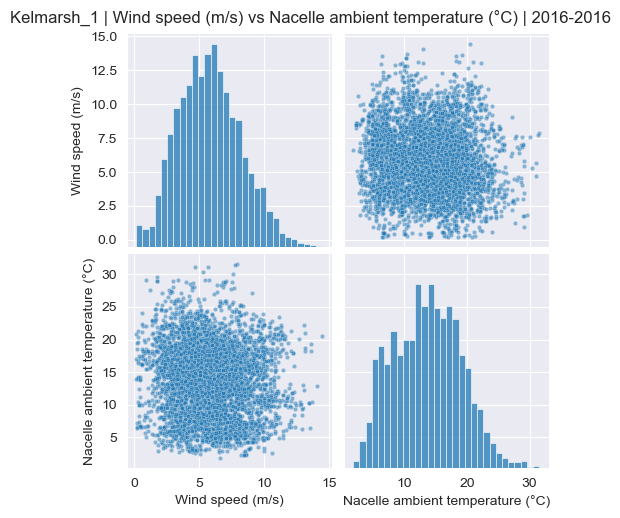

In [23]:
plot_feature_pair_distribution(
    turbine_name="Kelmarsh_1",
    feature_x="Wind speed (m/s)",
    feature_y="Nacelle ambient temperature (°C)",
    start_year=2016,
    end_year=2016,
    max_rows=5000,
)

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_correlation_heatmap(
    turbine_name: str,
    start_year: int,
    end_year: int,
    features: list[str] = None,
    method: str = "pearson",
    figsize=(10, 8),
):
    if features is None:
        features = INPUT_SIGNALS

    df = load_merged_scada_for_turbine(turbine_name)

    # 按年份过滤
    mask = (
        (df["Date and time"].dt.year >= start_year) &
        (df["Date and time"].dt.year <= end_year)
    )
    df_plot = df.loc[mask, ["Date and time"] + features].copy()

    # 去掉全部缺失的行
    df_plot = df_plot.dropna(subset=features, how="all").copy()

    if df_plot.empty:
        print("No data available for the selected turbine / year range.")
        return

    corr_df = df_plot[features].corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f"{turbine_name} | Feature Correlation Heatmap | {start_year}-{end_year} | method={method}")
    plt.tight_layout()
    plt.show()

    return corr_df

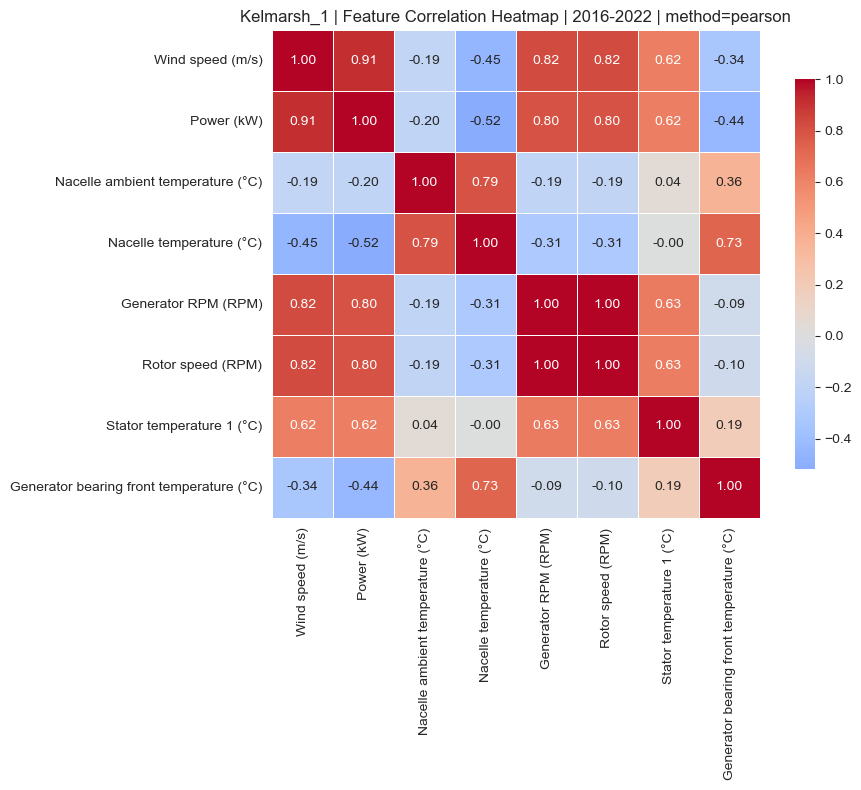

                                          Wind speed (m/s)  Power (kW)  \
Wind speed (m/s)                                  1.000000    0.911262   
Power (kW)                                        0.911262    1.000000   
Nacelle ambient temperature (°C)                 -0.186439   -0.197419   
Nacelle temperature (°C)                         -0.449653   -0.519049   
Generator RPM (RPM)                               0.824877    0.797446   
Rotor speed (RPM)                                 0.824317    0.796980   
Stator temperature 1 (°C)                         0.617260    0.616656   
Generator bearing front temperature (°C)         -0.336867   -0.441185   

                                          Nacelle ambient temperature (°C)  \
Wind speed (m/s)                                                 -0.186439   
Power (kW)                                                       -0.197419   
Nacelle ambient temperature (°C)                                  1.000000   
Nacelle temperature (

In [24]:
turbine_name = "Kelmarsh_1"
start_year = 2016
end_year = 2022
method = "pearson"   # 也可以改成 "spearman"

corr_df = plot_feature_correlation_heatmap(
    turbine_name=turbine_name,
    start_year=start_year,
    end_year=end_year,
    method=method,
)

print(corr_df)